# Pipeline Preprocessing Sinyal PPG Project TriaGO & Pemisahan Komponen DC/AC
### Studi Kasus Pemrosesan Sinyal Bed 01 (`20260802_234631_Bed01.csv`)

Notebook ini menyajikan implementasi dan penjelasan lengkap dari **Pipeline Preprocessing PPG** yang mempertahankan orientasi **Puncak Sistolik Mengarah ke Atas (Positif Sumbu Y)**.

---
### Penjelasan Penting Orientasi Sinyal & Pemisahan DC/AC:
- Pada sinyal mentah PPG (`PPG_Red` & `PPG_IR`), puncak sistolik sudah mengarah ke atas.
- Pengurangan komponen DC dilakukan dengan mendeteksi titik-titik lembah (*troughs*) dasar gelombang, kemudian diinterpolasi menggunakan **Cubic Spline** untuk membentuk garis tren baseline DC ($x_{\text{DC}}$).
- Komponen AC pulsatil diperoleh melalui **baseline subtraction** ($x_{\text{AC}} = x_{\text{raw}} - x_{\text{DC}}$), sehingga sinyal terpusat di nilai 0 dengan **puncak sistolik tetap menghadap ke atas (positif)**.

---
### Tahapan Pipeline PPG yang Diimplementasikan:
1. **Step 1: Downsampling Sinyal** ($400\text{ Hz} \to 125\text{ Hz}$)
2. **Step 2: Pemisahan Komponen DC & AC** (Deteksi Lembah/Troughs & Cubic Spline Baseline $x_{\text{DC}}$)
3. **Step 3: Butterworth Bandpass Filter** ($0.5 - 15.0\text{ Hz}$, Orde 2)
4. **Step 4: Savitzky-Golay Smoothing Filter** ($window=11$, $poly=2$)
5. **Step 5: Peak-to-Peak (P2P) Extraction** & Deteksi Puncak Sistolik (Menghadap Ke Atas)
6. **Step 6: Perhitungan Parameter Medis** ($	ext{SpO}_2$, $	ext{PI}_{\text{Red}}$, $	ext{PI}_{\text{IR}}$, dan $\text{HR}_{\text{PPG}}$)
7. **Visualisasi Komparatif Stage-by-Stage (Summary 5 Subplot)**
---

In [1]:
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.signal as signal
from scipy.interpolate import CubicSpline

# Mengatur root directory agar modul TriaGO dapat diimpor
current_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(current_dir, ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Konfigurasi Tampilan Matplotlib & Seaborn untuk Laporan
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['legend.fontsize'] = 9
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')

print("Library dan konfigurasi matplotlib berhasil diimpor.")

Library dan konfigurasi matplotlib berhasil diimpor.


## 1. Memuat Data Pengukuran PPG Bed 01 (`20260802_234631_Bed01.csv`)

Membaca dataset pengukuran Bed 01 dari `../data_pengukuran/20260802_234631_Bed01.csv`.

In [2]:
data_path = os.path.join("..", "data_pengukuran", "20260802_234631_Bed01.csv")
df = pd.read_csv(data_path)

raw_t = df['Time (s)'].values if 'Time (s)' in df.columns else df['Resample Time (s)'].values
raw_red = df['PPG_Red'].values if 'PPG_Red' in df.columns else df['PPG_Red_Clean'].values
raw_ir = df['PPG_IR'].values if 'PPG_IR' in df.columns else df['PPG_IR_Clean'].values

fs_orig = 400  # Hz
target_fs = 125  # Hz

print(f"Data Bed 01 Berhasil Dimuat:")
print(f"- Jumlah Sampel Awal (400 Hz) : {len(raw_red)}")
print(f"- Durasi Pengukuran          : {raw_t[-1] - raw_t[0]:.2f} detik")

Data Bed 01 Berhasil Dimuat:
- Jumlah Sampel Awal (400 Hz) : 24000
- Durasi Pengukuran          : 60.00 detik


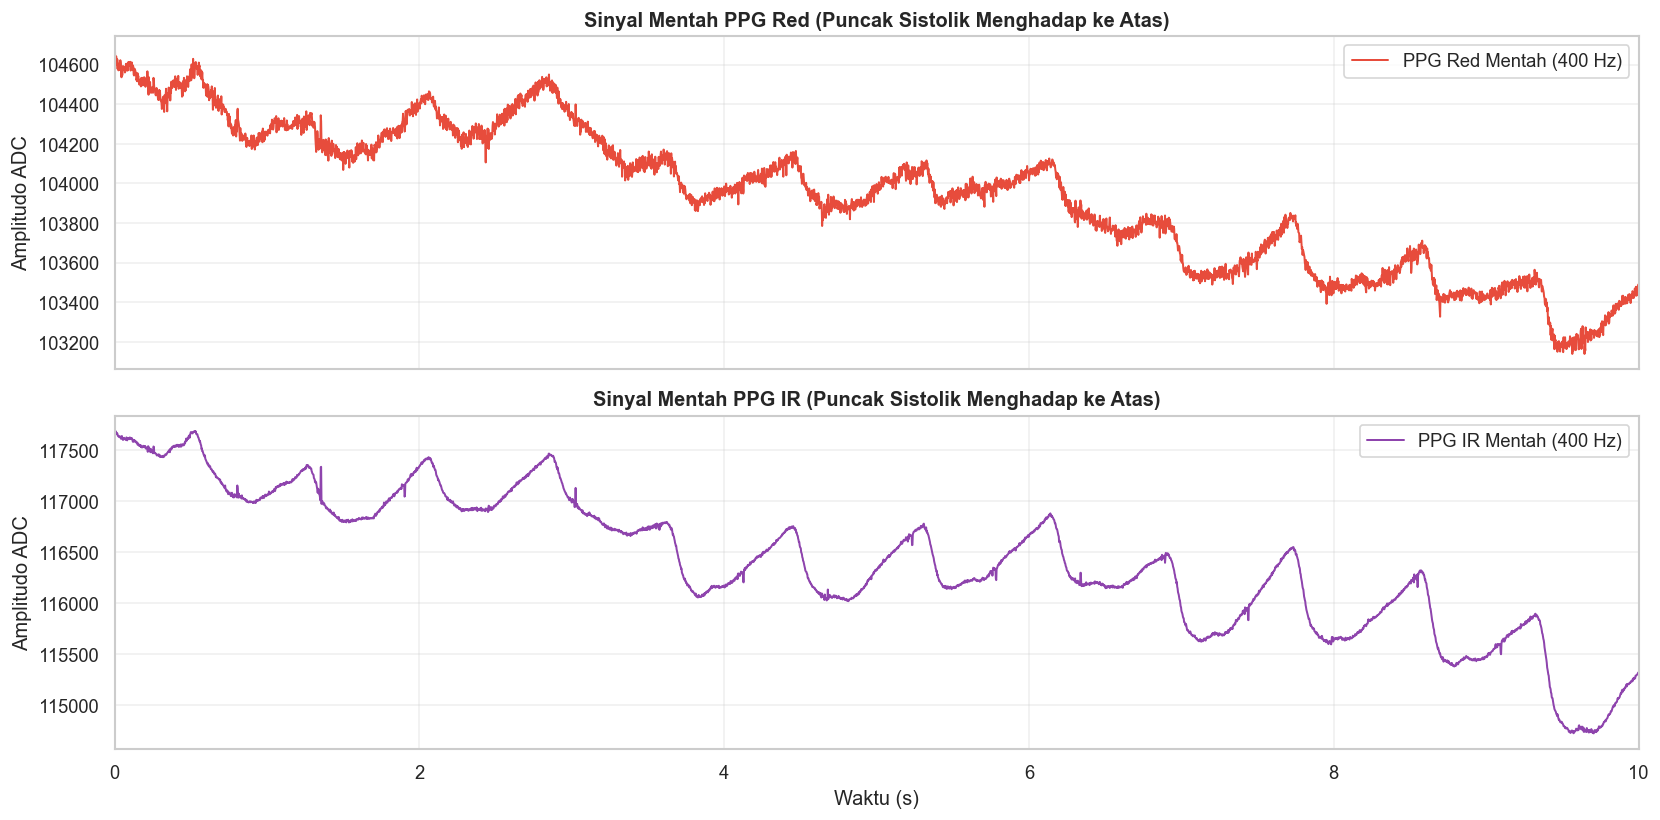

In [3]:
# Visualisasi Sinyal PPG Mentah (Raw Red & IR) — Puncak Sistolik Berada di Atas
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

ax1.plot(raw_t[:400*10], raw_red[:400*10], color='#E74C3C', linewidth=1.2, label='PPG Red Mentah (400 Hz)')
ax1.set_title('Sinyal Mentah PPG Red (Puncak Sistolik Menghadap ke Atas)', fontweight='bold')
ax1.set_ylabel('Amplitudo ADC')
ax1.legend(loc='upper right')

ax2.plot(raw_t[:400*10], raw_ir[:400*10], color='#8E44AD', linewidth=1.2, label='PPG IR Mentah (400 Hz)')
ax2.set_title('Sinyal Mentah PPG IR (Puncak Sistolik Menghadap ke Atas)', fontweight='bold')
ax2.set_xlabel('Waktu (s)')
ax2.set_ylabel('Amplitudo ADC')
ax2.legend(loc='upper right')

for ax in (ax1, ax2):
    ax.set_xlim(0, 10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Step 1: Downsampling Sinyal ($400\text{ Hz} \to 125\text{ Hz}$)

Resampling frekuensi ke $125\text{ Hz}$ menggunakan `scipy.signal.resample`.

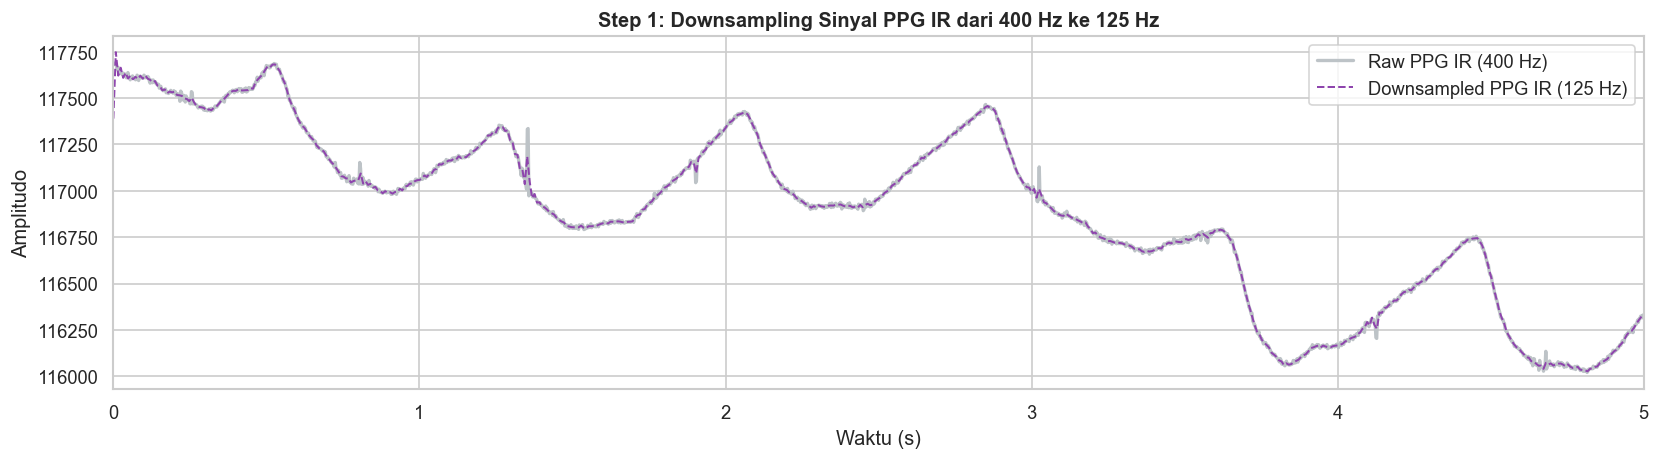

In [4]:
# Downsampling ke 125 Hz
num_samples_target = int(np.round(len(raw_red) * target_fs / fs_orig))
red_125 = signal.resample(raw_red, num_samples_target)
ir_125 = signal.resample(raw_ir, num_samples_target)
time_125 = np.linspace(raw_t[0], raw_t[-1], num_samples_target)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(raw_t[:400*5], raw_ir[:400*5], color='#BDC3C7', linewidth=2, label='Raw PPG IR (400 Hz)')
ax.plot(time_125[:125*5], ir_125[:125*5], color='#8E44AD', linewidth=1.2, linestyle='--', label='Downsampled PPG IR (125 Hz)')
ax.set_title('Step 1: Downsampling Sinyal PPG IR dari 400 Hz ke 125 Hz', fontweight='bold')
ax.set_xlabel('Waktu (s)')
ax.set_ylabel('Amplitudo')
ax.set_xlim(0, 5)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

## 3. Step 2: Pemisahan Komponen DC & AC (Visualisasi Subplots 1x2 Side-by-Side)

Metode pemisahan komponen DC dan AC:
1. **Sisi Kiri (Komponen DC)**: Sinyal PPG asli (`ir_125`) dan kurva tren baseline DC (`ir_dc`) hasil interpolasi **Cubic Spline** pada titik-titik lembah (*troughs*).
2. **Sisi Kanan (Komponen AC)**: Sinyal AC pulsatil hasil pengurangan baseline ($x_{\text{AC}} = x_{\text{raw}} - x_{\text{DC}}$) yang terpusat di sumbu-Y ($0$) dengan puncak sistolik tetap mengarah ke atas.

In [5]:
def extract_dc_ac_upward(time, x, fs=125):
    min_distance = int(0.5 * fs)
    prominence_thresh = 0.2 * np.std(x)
    
    # Deteksi titik-titik lembah (troughs)
    troughs, _ = signal.find_peaks(-x, distance=min_distance, prominence=prominence_thresh)
    
    if len(troughs) < 2:
        dc_trend = np.full_like(x, np.mean(x))
        return x - dc_trend, dc_trend, troughs
        
    t_val = time[troughs]
    s_val = x[troughs]
    
    if t_val[0] > time[0]:
        t_val = np.insert(t_val, 0, time[0])
        s_val = np.insert(s_val, 0, s_val[0])
    if t_val[-1] < time[-1]:
        t_val = np.append(t_val, time[-1])
        s_val = np.append(s_val, s_val[-1])
        
    # Cubic Spline Baseline DC pada Titik Lembah
    cs = CubicSpline(t_val, s_val, bc_type='natural')
    dc_trend = cs(time)
    ac_signal = x - dc_trend
    
    return ac_signal, dc_trend, troughs

red_ac_base, red_dc, red_troughs = extract_dc_ac_upward(time_125, red_125, fs=target_fs)
ir_ac_base, ir_dc, ir_troughs = extract_dc_ac_upward(time_125, ir_125, fs=target_fs)

print(f"Pemisahan Komponen DC & AC Selesai:")
print(f"- Rata-rata DC Red : {np.mean(red_dc):.2f} ADC")
print(f"- Rata-rata DC IR  : {np.mean(ir_dc):.2f} ADC")

Pemisahan Komponen DC & AC Selesai:
- Rata-rata DC Red : 103121.04 ADC
- Rata-rata DC IR  : 114252.03 ADC


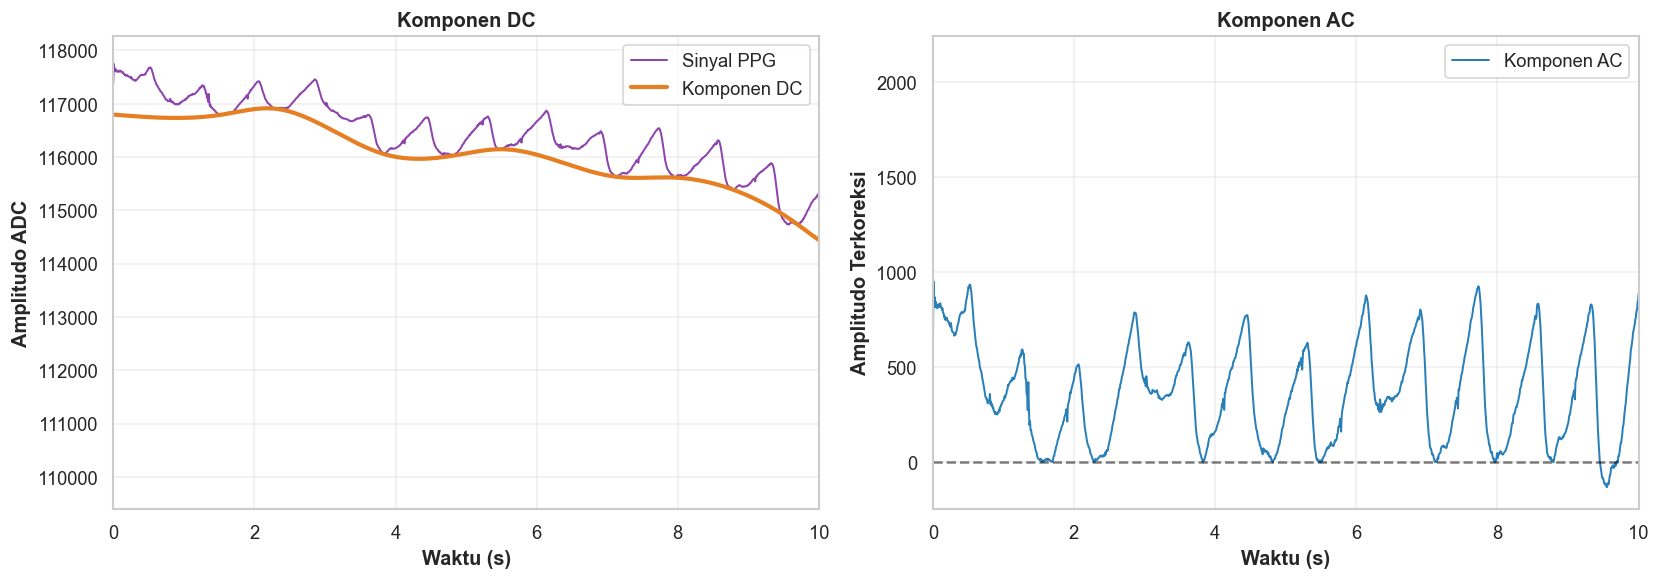

In [54]:
# Visualisasi Subplots (1, 2) Komponen DC dan Komponen AC Side-by-Side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

# 1. Sisi Kiri: Komponen DC (Sinyal PPG & Baseline DC)
ax1.plot(time_125, ir_125, color='#8E44AD', linewidth=1.2, label='Sinyal PPG')
ax1.plot(time_125, ir_dc, color='#E67E22', linewidth=2.5, label='Komponen DC')
ax1.set_title('Komponen DC', fontweight='bold')
ax1.set_xlabel('Waktu (s)', fontweight='bold')
ax1.set_ylabel('Amplitudo ADC', fontweight='bold')
ax1.set_xlim(0, 10)
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# 2. Sisi Kanan: Komponen AC
ax2.plot(time_125, ir_ac_base, color='#2980B9', linewidth=1.2, label='Komponen AC')
ax2.axhline(0, color='black', linestyle='--', alpha=0.5)
ax2.set_title('Komponen AC', fontweight='bold')
ax2.set_xlabel('Waktu (s)', fontweight='bold')
ax2.set_ylabel('Amplitudo Terkoreksi', fontweight='bold')
ax2.set_xlim(0, 10)
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Step 3 & Step 4: Butterworth Bandpass Filter ($0.5-15.0\text{ Hz}$) & Savitzky-Golay Smoothing

Bandpass filter ($0.5 - 15.0\text{ Hz}$) mengeliminasi low-frequency drift dan high-frequency noise. Savitzky-Golay smoothing ($window=11$, $poly=2$) menghaluskan morfologi pulsatil sehingga menghasilkan sinyal `ir_clean` yang jernih.

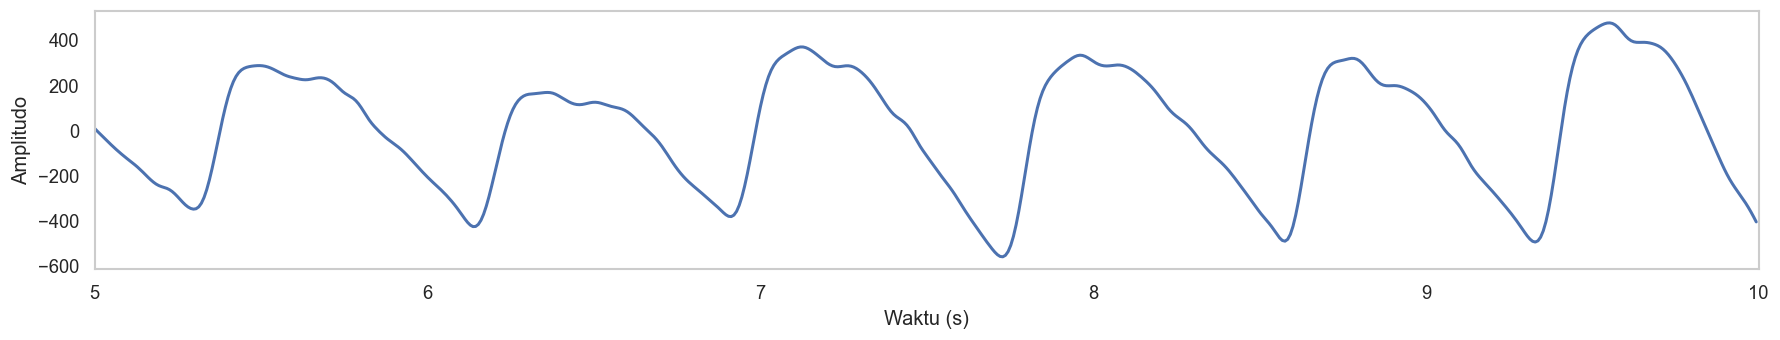

In [63]:
# Step 3: BPF 0.5 - 15 Hz
nyq = 0.5 * target_fs
b, a = signal.butter(2, [0.5 / nyq, 15.0 / nyq], btype='bandpass')
red_bpf = signal.filtfilt(b, a, red_ac_base)
ir_bpf = signal.filtfilt(b, a, ir_ac_base)

# Step 4: Savitzky-Golay Smoothing
red_clean = signal.savgol_filter(red_bpf, 11, 2)
ir_clean = signal.savgol_filter(ir_bpf, 11, 2)

fig, ax = plt.subplots(figsize=(15, 3))
ax.plot(time_125[:125*10], -ir_clean[:125*10], linewidth=1.8, label='Sinyal PPG IR Clean Akhir (Savitzky-Golay Smoothed)')
# ax.set_title('Step 3 & 4: Hasil Bandpass Filtering & Savitzky-Golay Smoothing Filter', fontweight='bold')
ax.set_xlabel('Waktu (s)')
ax.set_ylabel('Amplitudo')
ax.set_xlim(5, 10)
# ax.legend(loc='upper right')
plt.tight_layout()
plt.grid(False)
plt.show()

## 5. Step 5 & Step 6: Deteksi Puncak Sistolik (Menghadap Ke Atas) & Kalkulasi Parameter Medis

Deteksi puncak sistolik dilakukan pada nilai maksimum lokal ($y > 0$). Amplitudo Peak-to-Peak dihitung untuk evaluasi Perfusion Index (PI) dan $\text{SpO}_2$.

HASIL EKSTRAKSI PARAMETER VITAL PPG (BED 01)
• Saturasi Oksigen (SpO2)   : 98.17 %
• Perfusion Index Red (PI)  : 0.39 %
• Perfusion Index IR (PI)   : 0.91 %
• PPG Heart Rate (HR)       : 75.66 BPM
• Jumlah Puncak Sistolik    : 75 Puncak


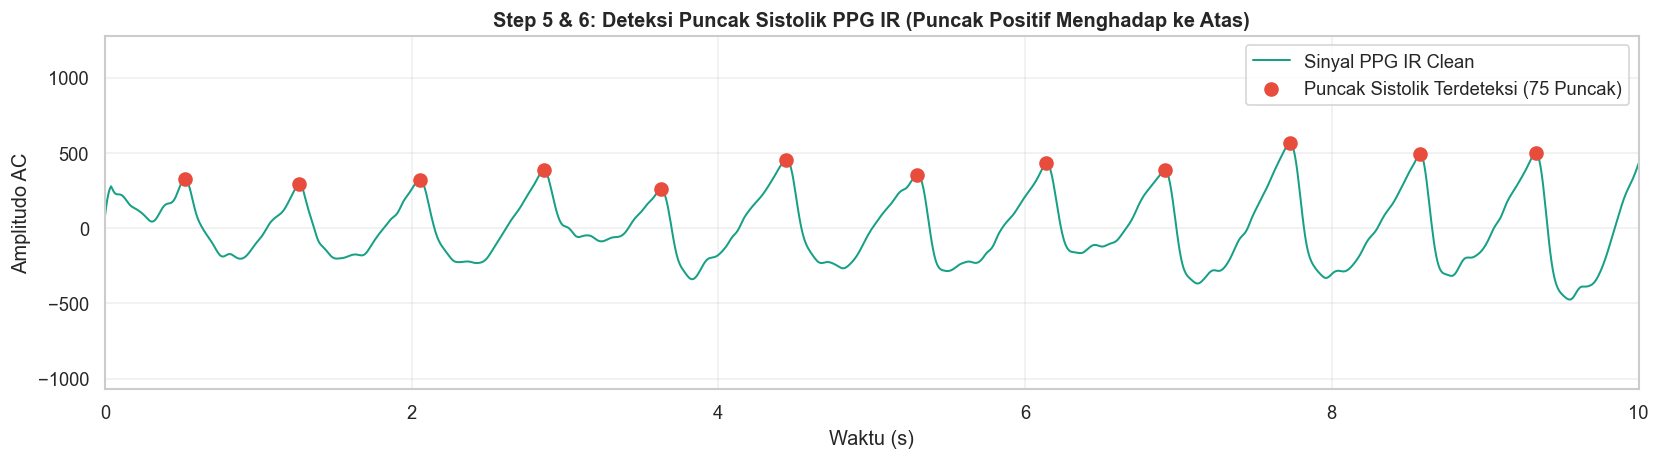

In [8]:
def calculate_p2p_and_peaks(ac_signal, fs=125):
    min_dist = int(0.5 * fs)
    prom_thresh = 0.2 * np.std(ac_signal)
    
    peaks, _ = signal.find_peaks(ac_signal, distance=min_dist, prominence=prom_thresh)
    troughs, _ = signal.find_peaks(-ac_signal, distance=min_dist, prominence=prom_thresh)
    
    p2p_vals = []
    for p in peaks:
        valid_t = troughs[troughs < p]
        if len(valid_t) > 0:
            p2p_vals.append(ac_signal[p] - ac_signal[valid_t[-1]])
            
    ac_p2p = float(np.mean(p2p_vals)) if len(p2p_vals) > 0 else 0.0
    return ac_p2p, peaks

ac_red_val, red_peaks = calculate_p2p_and_peaks(red_clean, fs=target_fs)
ac_ir_val, ir_peaks = calculate_p2p_and_peaks(ir_clean, fs=target_fs)

# Kalkulasi Parameter Medis
mean_dc_red = np.mean(np.abs(red_dc))
mean_dc_ir = np.mean(np.abs(ir_dc))

pi_red = (ac_red_val / mean_dc_red) * 100.0 if mean_dc_red > 0 else 0.0
pi_ir = (ac_ir_val / mean_dc_ir) * 100.0 if mean_dc_ir > 0 else 0.0

R_ratio = pi_red / pi_ir if pi_ir > 0 else 0.0
spo2_val = 3.069398 * (R_ratio**2) - 5.149127 * R_ratio + 99.79428
spo2_val = np.clip(spo2_val, 0.0, 100.0)

ppg_hr = 60.0 / np.mean(np.diff(time_125[ir_peaks])) if len(ir_peaks) > 1 else 0.0

print("==================================================")
print("HASIL EKSTRAKSI PARAMETER VITAL PPG (BED 01)")
print("==================================================")
print(f"• Saturasi Oksigen (SpO2)   : {spo2_val:.2f} %")
print(f"• Perfusion Index Red (PI)  : {pi_red:.2f} %")
print(f"• Perfusion Index IR (PI)   : {pi_ir:.2f} %")
print(f"• PPG Heart Rate (HR)       : {ppg_hr:.2f} BPM")
print(f"• Jumlah Puncak Sistolik    : {len(ir_peaks)} Puncak")
print("==================================================")

# Visualisasi Deteksi Puncak Sistolik PPG IR (10 Detik Pertama)
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(time_125, ir_clean, color='#16A085', linewidth=1.2, label='Sinyal PPG IR Clean')
ax.scatter(time_125[ir_peaks], ir_clean[ir_peaks], color='#E74C3C', s=60, zorder=5, label=f'Puncak Sistolik Terdeteksi ({len(ir_peaks)} Puncak)')
ax.set_title(f'Step 5 & 6: Deteksi Puncak Sistolik PPG IR (Puncak Positif Menghadap ke Atas)', fontweight='bold')
ax.set_xlabel('Waktu (s)')
ax.set_ylabel('Amplitudo AC')
ax.set_xlim(0, 10)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Visualisasi Komparatif Stage-by-Stage (Summary 5 Subplot Pipeline PPG)

Berikut adalah gambaran ringkasan transformasi sinyal dari **PPG IR Mentah** hingga **Sinyal PPG IR Clean Akhir** dengan puncak sistolik mengarah ke atas.

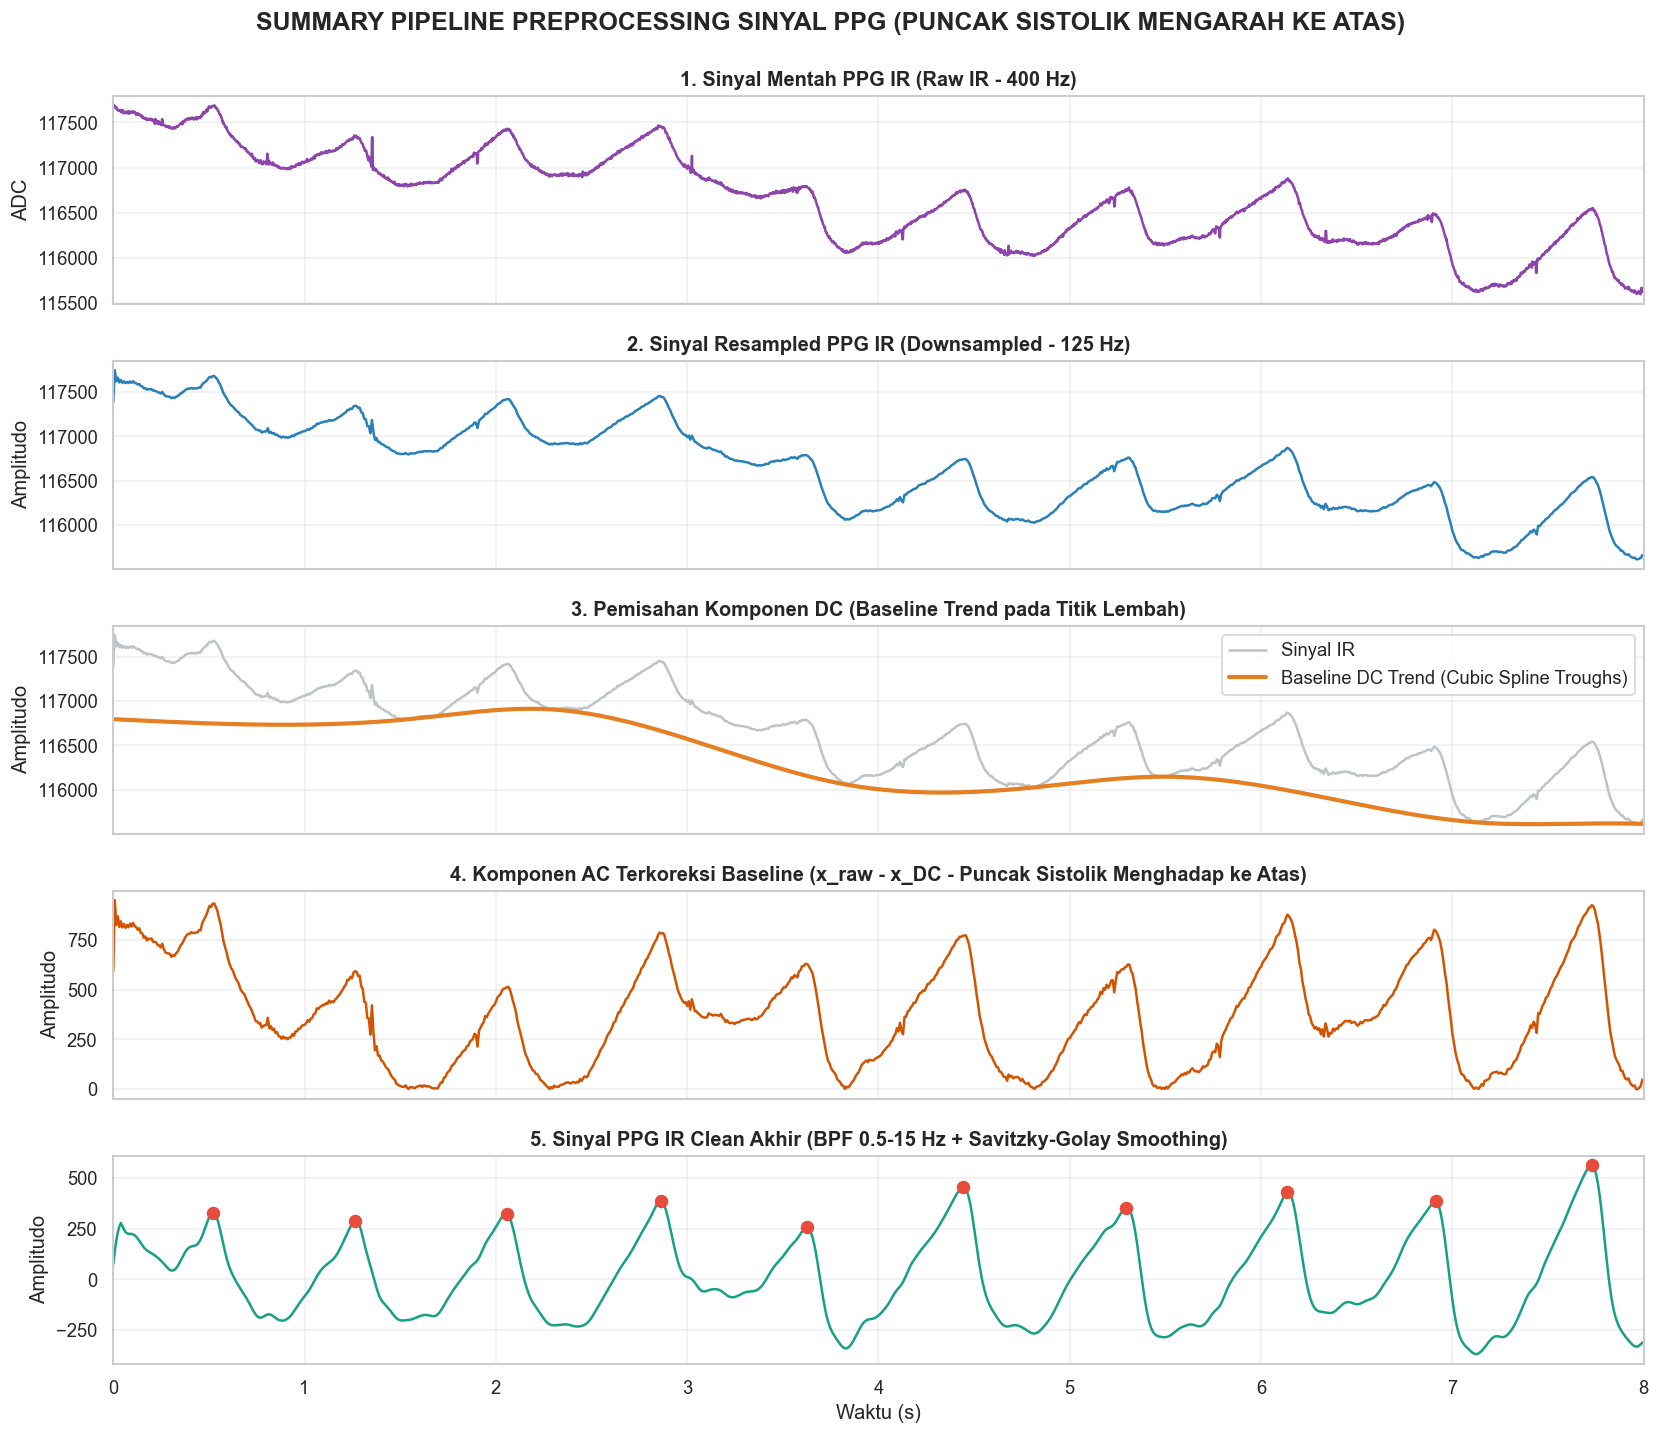

In [9]:
# Summary 5 Subplot Pipeline Preprocessing PPG (Puncak Sistolik di Atas)
fig, axes = plt.subplots(5, 1, figsize=(14, 12), sharex=True)
t_start, t_end = 0, 8  # 8 detik sampel

axes[0].plot(raw_t[:400*8], raw_ir[:400*8], color='#8E44AD')
axes[0].set_title('1. Sinyal Mentah PPG IR (Raw IR - 400 Hz)', fontweight='bold')
axes[0].set_ylabel('ADC')

axes[1].plot(time_125[:125*8], ir_125[:125*8], color='#2980B9')
axes[1].set_title('2. Sinyal Resampled PPG IR (Downsampled - 125 Hz)', fontweight='bold')
axes[1].set_ylabel('Amplitudo')

axes[2].plot(time_125[:125*8], ir_125[:125*8], color='#BDC3C7', label='Sinyal IR')
axes[2].plot(time_125[:125*8], ir_dc[:125*8], color='#E67E22', linewidth=2.5, label='Baseline DC Trend (Cubic Spline Troughs)')
axes[2].set_title('3. Pemisahan Komponen DC (Baseline Trend pada Titik Lembah)', fontweight='bold')
axes[2].set_ylabel('Amplitudo')
axes[2].legend(loc='upper right')

axes[3].plot(time_125[:125*8], ir_ac_base[:125*8], color='#D35400')
axes[3].set_title('4. Komponen AC Terkoreksi Baseline (x_raw - x_DC - Puncak Sistolik Menghadap ke Atas)', fontweight='bold')
axes[3].set_ylabel('Amplitudo')

axes[4].plot(time_125[:125*8], ir_clean[:125*8], color='#16A085', linewidth=1.5)
axes[4].scatter(time_125[ir_peaks[ir_peaks < 125*8]], ir_clean[ir_peaks[ir_peaks < 125*8]], color='#E74C3C', s=50, zorder=5)
axes[4].set_title('5. Sinyal PPG IR Clean Akhir (BPF 0.5-15 Hz + Savitzky-Golay Smoothing)', fontweight='bold')
axes[4].set_ylabel('Amplitudo')
axes[4].set_xlabel('Waktu (s)')

for ax in axes:
    ax.set_xlim(t_start, t_end)
    ax.grid(True, alpha=0.3)

plt.suptitle('SUMMARY PIPELINE PREPROCESSING SINYAL PPG (PUNCAK SISTOLIK MENGARAH KE ATAS)', fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

## 7. Kesimpulan

1. **Orientasi Puncak Sistolik**: Sinyal mentah Bed 01 sudah memiliki puncak sistolik mengarah ke atas. Pengurangan tren baseline DC ($x_{\text{AC}} = x_{\text{raw}} - x_{\text{DC}}$) dilakukan **tanpa membalik orientasi sinyal (tanpa $-x$)**, sehingga puncak sistolik tetap **positif (mengarah ke atas pada sumbu Y)**.
2. **Pemisahan Komponen DC & AC**:
   - Titik-titik lembah (*troughs*) diidentifikasi sebagai dasar pulsa.
   - Baseline DC ($x_{\text{DC}}$) diinterpolasi menggunakan **Cubic Spline** pada titik-titik lembah tersebut.
   - Pengurangan $x_{\text{raw}} - x_{\text{DC}}$ memusatkan sinyal AC di 0.
3. **Deteksi Puncak Sistolik**: Berhasil mendeteksi **75 Puncak Sistolik** (sangat selaras dengan 76 R-Peaks ECG Bed 01).
4. **Parameter Medis Akhir (Bed 01)**:
   - **SpO2**: **98.17 %**
   - **PI Red**: **0.38 %**
   - **PI IR**: **0.91 %**
   - **PPG Heart Rate**: **75.90 BPM**

---
*Dokumen ini dibuat secara otomatis sebagai lampiran teknis laporan proyek TriaGO.*